In [1784]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Functions 

## 1.1. Plotting functions

In [1786]:
def add_regions_mesh(pv_regions_dict, *,
                        plotter=None,
                        window_size= [800, 800],
                        notebook=True,
                        off_screen=False,
                        kwargs_dict=None, **kwargs):
    """
    Plot the PyVista mesh of a specified structure.
    Args:
        pv_regions_dict (dict): A dictionary of PyVista meshes for different brain regions.
        window_size (list, optional): Size of the plot window. Default is [800, 800].
        notebook (bool, optional): Whether to use notebook mode for the plotter. Default is True.
        off_screen (bool, optional): Whether to render the plot off-screen. Default is False.
        kwargs_dict (dict, optional): Additional keyword arguments for the mesh rendering.
    Returns:
        pv.Plotter: The PyVista plotter with the mesh added.
    """
    if plotter is None:
        plotter = pv.Plotter(notebook=notebook, window_size=window_size, 
                             off_screen=off_screen)
    default_kwargs = {
        'color': 'lightgrey',  # Default color for the mesh
        'opacity': 0.4,  # Default opacity for the mesh
    }

    if isinstance(pv_regions_dict, dict):
        for region in pv_regions_dict.keys():
            if kwargs_dict is not None:
                if region not in kwargs_dict.keys():
                    kwargs = default_kwargs
                else:
                    kwargs = kwargs_dict[region]
                kwargs['label'] = region if region != 'root' else 'Brain'
            elif isinstance(kwargs_dict, dict) and 'default' in kwargs_dict.keys():
                kwargs = default_kwargs
            else:
                kwargs = default_kwargs
            plotter.add_mesh(pv_regions_dict[region], **kwargs)
    else:
        try: 
            for key, value in default_kwargs.items():
                if key not in kwargs:
                    kwargs[key] = value
            plotter.add_mesh(pv_regions_dict, **kwargs)
        except KeyError as e:
            
            raise ValueError(f"Error: {e}. pv_regions_dict should be a dictionary with brain region meshes or the mesh.")
        
    plotter.add_axes()
    return plotter

In [1761]:

def add_3D_vol(doppler3D_vol,*, 
                    plotter = None,
                    notebook = True,
                    window_size = [700,700],
                    off_screen=False,
                    **kwargs):
    """
    Plot the ultrasound volume using PyVista.
    Args:
        doppler3D_vol (pv.ImageData): The ultrasound volume data.
        cmap (str): Colormap to use for the volume rendering.
        opacity (str or tuple): Opacity function for the volume rendering.
        clim (list): Color limits for the scalars.
    """
    if plotter is None:
        plotter = pv.Plotter(window_size=window_size, notebook=notebook,
                             off_screen=off_screen)
    
    default_kwargs = {
        'scalars': 'doppler',  # Assuming 'doppler' is a scalar field in doppler3D_vol
        'cmap': 'hot',
        'opacity': 'sigmoid',
        'mapper': 'smart',
        'show_scalar_bar': True,
        'scalar_bar_args': {
            'title': 'Doppler (dB)',
            "title_font_size": 16,
            "label_font_size": 12,
        },
    }
    for key, value in default_kwargs.items():
        if key not in kwargs:
            kwargs[key] = value
    
    vol = plotter.add_volume(doppler3D_vol, **kwargs)
    vol.prop.interpolation_type = 'linear'
    plotter.add_axes()
    return plotter

In [1762]:
def add_2D_image(image_grid,*, 
                plotter = None,
                notebook = True,
                window_size = [700,700],
                off_screen=False,
                **kwargs):
    """
    Plot the ultrasound volume using PyVista.
    Args:
        doppler3D_vol (pv.ImageData): The ultrasound volume data.
        cmap (str): Colormap to use for the volume rendering.
        opacity (str or tuple): Opacity function for the volume rendering.
        clim (list): Color limits for the scalars.
    """
    if plotter is None:
        plotter = pv.Plotter(window_size=window_size, notebook=notebook,
                                off_screen=off_screen)

    default_kwargs = {
        'show_edges':False,
        'cmap':'gray',
        'opacity':1.0,
        'name':'2D doppler',  # Name for the volume
        'show_scalar_bar':False,
        'show_scalar_bar': True,
        'scalar_bar_args': {
            'title': '2D Doppler (dB)',
            "title_font_size": 16,
            "label_font_size": 12,
            'vertical': True,
            'position_x': 0.1,
            'position_y': 0.2,
            "height": 0.3,
        },
    }
    for key, value in default_kwargs.items():
        if key not in kwargs:
            kwargs[key] = value

    vol=plotter.add_mesh(image_grid, **kwargs)
    plotter.add_axes()
    return plotter

In [1763]:
def add_pressure_vol(pressure_vol,*,
                    plotter=None,
                    window_size=[800, 800],
                    notebook=True,
                    plot_focal_spot = True,
                    off_screen=False,
                    **kwargs):
    
    if plotter is None:
        plotter = pv.Plotter(notebook=notebook, window_size=window_size,
                             off_screen=off_screen)

    # 3) Add the pressure volume
    if plot_focal_spot:
        
        default_kwargs = {
            'opacity': 1,
            'name' : "PressureIso",
            'show_scalar_bar': False,
            'label': "Focal Spot",  # label for the legend
            'color' : "r", # color of the mesh
        }
        for key, value in default_kwargs.items():
            if key not in kwargs:
                kwargs[key] = value
                
        # pick a threshold, e.g. halfway to the max
        threshold = 0.7 * pressure_vol["Pressure"].max()
        iso_mesh = pressure_vol.contour([threshold], scalars="Pressure")  # Create isosurface at threshold# add that instead of (or in addition to) the volume
        plotter.add_mesh(iso_mesh, **kwargs)    

    else:
        n_contours = 10
        min_val = 0
        max_val = pressure_vol["Pressure"].max()
        levels = np.linspace(min_val, max_val, n_contours)
        iso_mesh = pressure_vol.contour(isosurfaces=levels, scalars="Pressure")  # Create isosurface at threshold
        default_kwargs = {
            'scalars': "Pressure",  # use the scalar to color surfaces
            'opacity': 'linear',
            'cmap' : "jet",
            'show_scalar_bar': True,
            'scalar_bar_args': {
                'title': 'Pressure (u.a.)',
                "title_font_size": 16,
                "label_font_size": 12,
                'vertical': True,
                'position_x': 0.85,
                'position_y': 0.2,
                "height": 0.3,
            },
            'label': "Pressure PII",  # label for the legend
            'color' : "r", # color of the mesh
        }
        for key, value in default_kwargs.items():
            if key not in kwargs:
                kwargs[key] = value

        plotter.add_mesh(iso_mesh, **kwargs)

    plotter.add_axes()
    return plotter

In [1764]:
def add_transducer_mesh(TX_mesh, *,
                        plotter=None,
                        window_size=[800, 800],
                        notebook=True,
                        off_screen=False,
                        **kwargs):
    
    if plotter is None:
        plotter = pv.Plotter(notebook=notebook, window_size=window_size,
                             off_screen=off_screen)

    default_kwargs = {
        'scalars': 'Apodization',  # Assuming 'Apodization' is a scalar field in TX_mesh
        'cmap': 'cool',
        'clim': [0, 1],
        'opacity': 1.0,
        'show_edges': True,
        'show_scalar_bar': True,
        'scalar_bar_args': {
            'title': 'Apodization',
            "title_font_size": 16,
            "label_font_size": 12,
            'vertical': True,
            'position_x': 0.85,
            'position_y': 0.5,
            "height": 0.3,
        },
    }

    for key, value in default_kwargs.items():
        if key not in kwargs:
            kwargs[key] = value

    plotter.add_mesh(TX_mesh,   # Convert to mm for visualization
            **kwargs
        )
    plotter.add_axes()
    return plotter


## 1.2. DopplerScan class

In [1765]:
import matplotlib.pyplot as plt
import numpy as np
import h5py

def read_scan(path_scan, verbose = False):
    """
    Read a 3D scan from a given path and return the data and metadata.
    Args:
        path_scan (str): Path to the .scan file.
        verbose (bool): If True, print additional information about the scan.
    Returns:
        tuple: A tuple containing the data and metadata from the scan.
    """
    
    file_scan = h5py.File(path_scan, "r") 
    data = file_scan['Data'][()]
    metadata = file_scan['acqMetaData']
    # metadata = {key: raw_metadata[key][()] for key in raw_metadata.keys()}


    if verbose:
        print("\n------scan keys------")
        print(file_scan.keys())
        for key in file_scan.keys():
            print(f"{key}: {file_scan[key]} ")
        print("\ndata shape:", data.shape)
        print("\n-----aqui. metadata keys------")
        for key in metadata.keys():
            print(f"{key}  : {metadata[key]}")

    return data, metadata

def read_bps(path_bps, verbose = False):
    """
    Read a BPS file and return BrainToLab affine matrix.
    Args:
        path_bps (str): Path to the .bps file.
        verbose (bool): If True, print additional information about the BPS file.
    Returns:
        tuple: A tuple containing the BrainToLab affine matrix.
    """
    
    metadata_bps = h5py.File(path_bps, "r") 
    # metadata_bps = {key: raw_metadata_bps[key][()] for key in raw_metadata_bps.keys()}

    if verbose:
        print("------bps keys------")
        print(metadata_bps.keys())
        for key in metadata_bps.keys():
            print(f"{key}: {metadata_bps[key].shape} {metadata_bps[key].dtype}")
    return metadata_bps


def volume3D_from_scan_stack(scan_stack_data,*, probe_type = 'Linear', mean_frames = True, verbose = False):
    """
    Process a 3D scan data array and return a 3D data array suitable for visualization.
    Args:
        scan3D_data (np.ndarray): 5D array with shape (N_scan, frames, Z_vox, Y_vox, X_vox).
        probe_type (str): Type of probe used for the scan ('Linear' or other).
        verbose (bool): If True, print additional information about the processing.
    Returns:
        np.ndarray: A 3D array with shape (X_vox, Y_vox, Z_vox) suitable for visualization.
    """

    if scan_stack_data.ndim != 5:
        raise ValueError("Input scan3D_data must be a 5D array with shape (N_scan, frames, Z_vox, Y_vox, X_vox)")
    
    n_scan, nt, nz, ny, nx = scan_stack_data.shape

    if mean_frames and nt > 1:
        # If mean_frames is True, average over the time dimension
        print(scan_stack_data)
        scan_stack_data = np.mean(scan_stack_data, axis=1, keepdims=True)
        print(scan_stack_data)
    else:
        scan_stack_data = scan_stack_data[:,0,:,:,:]

    if probe_type == 'Linear':
        if ny != 1:
            raise ValueError("For linear probes, the Y dimension should be 1.")
        # For linear probes, we assume N_scan corresponds to different scan lines, and we want to
        # create a 3D volume where each scan line is a slice in the Y dimension.
        # Thus, we assume dy (distance between adjacent scan lines) is small
        # enough to consider it as a voxel in the Y dimension.

        stack_processed = scan_stack_data.squeeze().transpose([2, 0, 1])
    else:
        print(f"Probe type {probe_type} not recognized. Returning original data.")
        stack_processed = scan_stack_data

    if verbose:
        print("Processing scan stack data...")
        print("Original scan_stack_data shape:", scan_stack_data.shape)
        print("Processed scan_stack_data shape:", stack_processed.shape)
    
    return stack_processed

# -------------------------------------------------------------------------------------------------

def image2D_from_scan(scan_data,*, probe_type = 'Linear', mean_frames = True, verbose = False):
    """
    Process a 2D scan data array and return a 2D data array suitable for visualization.
    Args:
        scan_data (np.ndarray): 4D array with shape (frames, Z_vox, Y_vox, X_vox).
        probe_type (str): Type of probe used for the scan ('Linear' or other).
        mean_frames (bool): If True, average over the time dimension.
        verbose (bool): If True, print additional information about the processing.
    Returns:
        np.ndarray: A 2D array with shape (X_vox, Y_vox=1, Z_vox) suitable for visualization.
    """

    if scan_data.ndim != 4:
        raise ValueError("Input scan_data must be a 4D array with shape (frames, Z_vox, Y_vox, X_vox)")
    
    nt, nz, ny, nx = scan_data.shape

    if mean_frames and nt > 1:
        # If mean_frames is True, average over the time dimension
        scan_data = np.mean(scan_data, axis=0, keepdims=False)
    else:
        scan_data = scan_data[0,:,:,:]

    if probe_type == 'Linear':
        if ny != 1:
            raise ValueError("For linear probes, the Y dimension should be 1.")
        
        scan_processed = scan_data.transpose([2, 1, 0])
    else:
        print(f"Probe type {probe_type} not recognized. Returning original data.")
        scan_processed = scan_data

    if verbose:
        print("Processing scan data...")
        print("Original scan_data shape:", scan_data.shape)
        print("Processed scan_data shape:", scan_processed.shape)
    return scan_processed

# -------------------------------------------------------------------------------------------------

def create_3D_volume_mesh(data):
    """
    Create a 3D mesh from the processed scan data for Doppler visualization.
    Args:
        processed_scan_3D (np.ndarray): The processed 3D scan data.
        clip (tuple, optional): A tuple of two values (minclip_value, maxclip_value) to clip the Doppler data.
    Returns:
        pv.Plotter: The PyVista plotter with the Doppler mesh added.
    """

    # Create the 3D UniformGrid
    doppler3D_voxels = pv.ImageData(
        dimensions = data.shape
    )

    # Attach pressure data to the grid
    doppler3D_voxels.point_data["doppler"] = data.ravel(order="F")  # VERY important: Fortran order

    return doppler3D_voxels

# -------------------------------------------------------------------------------------------------

def create_2D_image_mesh(data): 
    """
    Compute a 2D image mesh from a B-mode ultrasound image and a transformation matrix.
    Args:
        data (np.ndarray): 2D array of B-mode ultrasound data in dB.
    Returns:
        pv.StructuredGrid: A structured grid representing the 2D image in world coordinates.
    """
    H, W = data.shape

    # Create grid indices
    i_grid, j_grid = np.meshgrid(np.arange(W), np.arange(H))

    # Construct homogeneous voxel coordinates [j, 0, i, 1]
    points_voxel = np.stack([j_grid, np.zeros_like(j_grid), i_grid, np.ones_like(j_grid)], axis=-1)
    points_voxel_flat = points_voxel.reshape(-1, 4).T  # Shape (4, H*W)
    
    points_voxel_flat  # Shape (4, H*W)

    # Create structured grid
    xx = points_voxel_flat[0].reshape(H, W)
    yy = points_voxel_flat[1].reshape(H, W)
    zz = points_voxel_flat[2].reshape(H, W)
    grid = pv.StructuredGrid(xx, yy, zz)
    grid["doppler"] = data.ravel(order="F").astype(np.float32)  # Add scalar data # FORTRAN ORDER IMPORTANT
    return grid

# -------------------------------------------------------------------------------------------------


def create_3D_doppler_mesh(processed_scan_3D, *, clip = None):
    """
    Create a 3D mesh from the processed scan data for Doppler visualization.
    Args:
        processed_scan_3D (np.ndarray): The processed 3D scan data.
        clip (tuple, optional): A tuple of two values (minclip_value, maxclip_value) to clip the Doppler data.
    Returns:
        pv.Plotter: The PyVista plotter with the Doppler mesh added.
    """

    # Convert processed_scan_3D to dB scale
    Doppler_dB = 20 * np.log10(np.abs(processed_scan_3D) / np.max(np.abs(processed_scan_3D)))
    if clip is not None:
        Doppler_dB = np.clip(Doppler_dB, clip[0], clip[1])

    # Create the 3D UniformGrid
    doppler3D_voxels = pv.ImageData(
        dimensions = Doppler_dB.shape
    )

    # Attach pressure data to the grid
    doppler3D_voxels.point_data["doppler"] = Doppler_dB.ravel(order="F")  # VERY important: Fortran order

    return doppler3D_voxels   


In [1766]:
class DopplerScan:
    def __init__(self, scan_PATH = None, bps_PATH = None, *,
                 probe_type = 'Linear', mean_frames = True, verbose = False):

        self.scan_PATH = scan_PATH
        self.bps_PATH = bps_PATH
        self.probe_type = probe_type
        self.mean_frames = mean_frames
        self.verbose = verbose
        self.load_scan(scan_PATH, bps_PATH = bps_PATH)
        self.reset_mesh() # Initialize the PyVista mesh attribute

        
    def load_scan(self, scan_PATH, bps_PATH = None):
        """
        Load the scan data from the specified path and pre-process it.
        Args:
            scan_PATH (str): The path to the scan file.
            bps_PATH (str, optional): The path to the BPS file. If None, no BPS metadata will be loaded.
        """

        try :
            # Load the scan data from the file
            scan_data, scan_metadata = read_scan(scan_PATH)
        except Exception as e:
            raise ValueError(f"Error loading scan data from {scan_PATH}: {e}")
        
        print(f"Scan data loaded from {scan_PATH}. Shape: {scan_data.shape}")
        self.scan_PATH = scan_PATH

        # Pre-process it
        if scan_data.ndim == 5:
            # If the scan data is 5D, we assume it is a stack of 2D scans
            # [N_scan, frames, Z_vox, Y_vox, X_vox] (2D, then Y_vox is 1)
            self.data = volume3D_from_scan_stack(scan_data,
                        probe_type=self.probe_type, mean_frames=self.mean_frames, verbose=self.verbose)
            self.scan_type = "3D"
        elif scan_data.ndim == 4:
            # If the scan data is 4D, we assume it is a single 2D scan
            # [frames, Z_vox, Y_vox, X_vox]  (2D, then Y_vox is 1)
            self.scan_type = "2D"
            self.data = image2D_from_scan(scan_data,
                         probe_type=self.probe_type, mean_frames=self.mean_frames, verbose=self.verbose)
        else:
            raise ValueError("Input scan_data must be a 4D or 5D array with shape (frames, Z_vox, Y_vox, X_vox) or (N_scan, frames, Z_vox, Y_vox, X_vox)")
        
        self.probeToLab = scan_metadata["probeToLab"][()]    
        print(f"Probe to Lab transformation matrix loaded. Shape: {self.probeToLab.shape}")
        if self.probeToLab.ndim == 3 :
            # If probeToLab is a 3D array, we assume the first slice corresponds to the probe to lab transformation
            print("Probe to Lab transformation matrix is 3D. Taking the first slice.")
            self.probeToLab = self.probeToLab[0].squeeze()
        elif self.probeToLab.ndim > 3 or self.probeToLab.shape != (4, 4):
            raise ValueError("probeToLab must be a 3D array with shape (4, 4) or (N_scan, 4, 4)")
        
        self.voxelsToProbe = scan_metadata["voxelsToProbe"][()]

        # Attributes to hold the scan data and metadata
        self.set_qform(self.get_qform())
        self.set_sform(self.get_sform(bps_PATH = bps_PATH))
        del scan_data, scan_metadata  # Free memory
        print(f"DopplerScan {self.scan_type} object created successfully.")

    def set_qform(self, qform):
        """
        Set the qform matrix for the scan.
        Args:
            qform (np.ndarray): The qform matrix to set.
        """
        self.qform = qform
    
    def set_sform(self, sform):
        """
        Set the sform matrix for the scan.
        Args:
            sform (np.ndarray): The sform matrix to set.
        """
        self.sform = sform
    
    def reset_mesh(self):
        """
        Set the PyVista mesh for the scan.
        Args:
            pv_mesh (pv.Plotter): The PyVista mesh to set.
        """
        self.pv_mesh = self.get_mesh(self.qform)
        print("PyVista mesh reset on Lab coordinate system.")

        
    def get_qform(self) :    
        invert_z = np.diag([1, 1, -1, 1])  # Invert z-axis
        # We must invert the z-axis to match the probe coordinate system
        return  invert_z @ self.probeToLab @ self.voxelsToProbe  # voxel -> scabber (Lab) coordinates transformation
        
    def get_sform(self, bps_PATH):

        if bps_PATH is not None:
            print("BPS path provided. Using it to compute the sform matrix.")
            self.bps_PATH = bps_PATH # Reset the BPS path on the object

        elif self.bps_PATH is not None:
            print("No BPS path provided, but BPS path was found on the scan object.")
        else:
            print("No BPS path provided. No way to get to the Brain space. Returning s_form as identity.")
            return np.eye(4)
        
        bps_metadata = read_bps(self.bps_PATH, verbose=False)
        self.BrainToLab = bps_metadata['BrainToLab'][()]

        del bps_metadata
        invert_z = np.diag([1, 1, -1, 1])  # Invert z-axis

        return  invert_z @ np.linalg.inv(self.BrainToLab) @ invert_z @  self.qform # voxel -> anatomical (Brain) coordinates transformation
        
    def get_mesh(self, T_matrix = None, *, dB = True) :

        if dB:
            data = self.dB(inplace = False)
        else:
            data = self.data

        if self.scan_type == "3D":
            # Create a 3D mesh from the scan data
            mesh = create_3D_volume_mesh(data)
        elif self.scan_type == "2D":
            # Create a 2D mesh from the scan data
            mesh = create_2D_image_mesh(data.squeeze())
        else:
            raise ValueError("Something went wrong when loading the scan data. \n" \
            "The scan type should be either '3D' or '2D', but it is not recognized.")
        
        if T_matrix is not None:
            # If a transformation matrix is provided, apply it to the mesh
            mesh.transform(T_matrix, inplace=True)
        
        return mesh
    
    def transform(self, pv_mesh = None, T_matrix = None, *, inplace = False):
        """
        Transform the scan data using a transformation matrix.
        Args:
            T_matrix (np.ndarray): The transformation matrix to apply.
            inplace (bool): If True, modify the scan data in place.
        Returns:
            np.ndarray: The transformed scan data.
        """
        if self.pv_mesh is None and pv_mesh is None:
            raise ValueError("No mesh provided. pv_mesh is NONE.")

        if pv_mesh is None and not inplace:
            pv_mesh = self.pv_mesh.copy()
        elif pv_mesh is None and inplace: # if inplace, transform the existing mesh
            pv_mesh = self.pv_mesh
        
        if T_matrix is not None:
            pv_mesh.transform(T_matrix, inplace=True)
        else:
            print("No transformation matrix provided. No transformation applied to the mesh.")
        return pv_mesh

    def dB(self, data = None, *, inplace = False) :

        """
        Convert the scan data to dB scale.
        Args:
            data (np.ndarray): The scan data to convert.
        Returns:
            np.ndarray: The scan data in dB scale.
        """
        if data is None:
            data = self.data

        if np.any(data == 0):
            print("Data contains zero values. Cannot compute dB scale. No convertion to dB is done.")
            return data

        if inplace:
            self.data = 20 * np.log10(np.abs(data) / np.max(np.abs(data)))
            return self.data
        else:
            return 20 * np.log10(np.abs(data) / np.max(np.abs(data)))
        
    def show(self,*, dB = True, **kwargs): 

        nx, ny, nz = self.data.shape
        print(f"Plotting y-planes of scan with shape ({nx}, {ny}, {nz})")

        if self.scan_type == "3D":
            ncols = 9
            nrows = ny // ncols + (ny % ncols > 0)
        else:
            ncols = 1
            nrows = 1
        
        fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*5), facecolor = 'black')

        ax = ax.flatten() if nrows > 1 else [ax]
        if dB:
            for i in range(ny):
                ax[i].imshow(self.dB(self.data[:, i, :].squeeze().T), cmap='gray', **kwargs)
                ax[i].set_title(f"Y-plane {i+1}", color='white')
                ax[i].axis('off')
        else:
            for i in range(ny):
                ax[i].imshow(self.data[:, i, :].squeeze().T, cmap='gray', **kwargs)
                ax[i].set_title(f"Y-plane {i+1}", color='white')
                ax[i].axis('off')
        
        for i in range(ny, nrows * ncols):
            ax[i].axis('off')
        
        plt.tight_layout()
        plt.show()

    def summary(self) :
        """
        Print a summary of the DopplerScan object.
        """
        print("----------DopplerScan Summary:----------")
        for key, value in self.__dict__.items():
            if key == 'data':
                if isinstance(value, np.ndarray):
                    print(f"{key}: array with shape {value.shape}")
                else:
                    print(f"{key}: {value}")
            else:
                print(f"{key}: {value}")

    def __repr__(self):
        return f"DopplerScan(scan_PATH={self.scan_PATH}, bps_PATH={self.bps_PATH}, probe_type={self.probe_type}, mean_frames={self.mean_frames}, scan_type={self.scan_type})"
    


    

## 1.3. BG_Atlas class

In [1767]:
from brainglobe_atlasapi import BrainGlobeAtlas
from brainglobe_atlasapi import show_atlases as bg_show_atlases
import brainglobe_space as bg_space

class BG_Atlas:
    def __init__(self, atlas_name = 'whs_sd_rat_39um', region_names='root', *,
                 show_atlases = False,
                 whs_voxels = None, manual_fit = None, verbose = False):
        
        if show_atlases:
            bg_show_atlases()
        self.atlas_name = atlas_name
        self.bg_atlas = BrainGlobeAtlas(atlas_name)
        
        self.region_names = region_names
        self.whs_voxels = whs_voxels
        self.manual_fit = manual_fit
        self.verbose = verbose

        self.bgatlasToBrain = self.get_bgatlasToBrain(self.bg_atlas,
                     whs_voxels = self.whs_voxels, manual_fit = self.manual_fit, verbose = self.verbose)  # Get the transformation matrix from BrainGlobe Atlas to Brain-space (BPS Atlas)

        self.reset_mesh()
        print(f"BrainGlobe Atlas '{self.atlas_name}' loaded successfully.")

    def get_bgatlasToBrain(self, bg_atlas, *, whs_voxels = None, manual_fit = None, verbose = False):
        """
        Compute the transformation matrix from BrainGlobe Atlas to Brain-space (BPS Atlas).
        Args:
            bg_atlas (BrainGlobeAtlas): The BrainGlobe Atlas object.
            brain_mesh_dict (dict, optional): A dictionary of PyVista meshes for different brain regions.
            whs_voxels (dict, optional): A dictionary containing the WHS origin, bregma, and lambda voxels.
        Returns:
            np.ndarray: The transformation matrix from BrainGlobe Atlas to Brain-space (BPS Atlas).
            transformed_brain_mesh_dict (dict, optional): A dictionary of transformed PyVista meshes for different brain regions, if provided.
        """
        name = bg_atlas.metadata['name']
        # Get the information to compute transformation matrix
        resolution = np.array(bg_atlas.metadata['resolution']) 

        if  name == "whs_sd_rat":
            # We need to apply a specific transformation to align the BrainGlobe atlas
            # with the WHS atlas space.
            print(f"WHS origin, bregma, and lambda coordinates available for `{name}`.")
            whs_voxels = {
            'origin' : np.array([244, 623, 248]),
            'bregma' : np.array([246, 653, 440]),
            'lambda' : np.array([244, 442, 434]),
            }
        elif name == "allen_mouse":
            # We need to apply a specific transformation to align the BrainGlobe atlas
            # with the WHS atlas space.
            print(f"WHS origin, bregma, and lambda coordinates available for `{name}`.")
            manual_fit = {
            'origin' : np.array([228, 330, 118]),
            'bregma_lambda_um' : 2300,  # Distance between bregma and lambda in micrometers (4mm)
            }
        elif whs_voxels is not None:
            # If whs_voxels is provided, we use it to align the atlas
            print("Using provided WHS voxels for alignment.")
            pass
        elif manual_fit is not None:
            # If manual_fit is provided, we use it to align the atlas
            print("Using provided manual fit for alignment.")
            pass
        else:
            print("WARNING: No available information for this atlas. \n" \
            "To compute BrainGlobe to Brain-space, the WHS origin, bregma, and lambda voxels must be provided, \n" \
            "or a manual fit could be done by setting the `manual_fit` dict with bregma_sigma_um and origin_voxel keys.\n" \
            "No subject normalization will be applied, and the atlas will be returned in its voxel space.")

        if whs_voxels is not None:
            bregma2lambda = np.linalg.norm((whs_voxels['lambda'] - whs_voxels['bregma']))
            normalize_bregma2sigma =  np.diag(np.concatenate(([1/bregma2lambda]*3, [1])))  # Add a 1 for homogeneous coordinates
            set_whs_origin = np.eye(4)
            set_whs_origin[:3, 3] = -whs_voxels['origin']
            
        elif manual_fit is not None:
            # If bregma_lambda_mm is provided, we use it scale the atlas
            bregma2lambda = np.linalg.norm(manual_fit['bregma_lambda_um']/resolution)
            normalize_bregma2sigma =  np.diag(np.concatenate(([1/bregma2lambda]*3, [1])))        
            set_whs_origin = np.eye(4)
            set_whs_origin[:3, 3] = -manual_fit['origin']

        else:
            normalize_bregma2sigma = np.eye(4)
            set_whs_origin = np.eye(4)

        # Take to whs orientation RAS+
        target_space = bg_space.AnatomicalSpace("lpi") # New resolution to change the units from um to mm
        set_whs_orientation = bg_atlas.space.transformation_matrix_to(target_space)

        # Create the transformation matrix from BrainGlobe Atlas to whs Atlas
        resolution2Voxel =  np.diag(np.concatenate((1/resolution, [1])))  # Add a 1 for homogeneous coordinates

        # Create the transformation matrix from BrainGlobe Atlas to BPS Atlas
        bgatlasToBrain =  normalize_bregma2sigma @ set_whs_origin @ set_whs_orientation @ resolution2Voxel 

        if verbose:
            print("resolutionToVoxel:\n", resolution2Voxel)    
            print("set_whs_orientation:\n", set_whs_orientation)    
            print("set_whs_origin:\n", set_whs_origin)    
            print("normalize_bregma2sigma:\n", normalize_bregma2sigma)    
            print("bgatlasToBrain:\n", bgatlasToBrain)    

        return bgatlasToBrain
    
    def get_pv_mesh_from_atlas(self, bg_atlas, region_names):
        """
        Get a PyVista mesh from the BrainGlobe Atlas for a given structure name.
        Args:
            bg_atlas (BrainGlobeAtlas): The BrainGlobe Atlas object.
            structure_name (str or list/tuple/set): The name of the structure(s) to retrieve.
        Returns:
            pv_mesh (dict): A dictionary containing the PyVista mesh(es) for the specified structure(s).
        """
        pv_mesh = {}
        if not isinstance(region_names, str):
            try:
                n_reg = len(region_names)            
                for i, region_name in enumerate(region_names):
                    print(f"Processing region {i+1}/{n_reg}: {region_name}")
                    print(f"Found structure: {bg_atlas.structures[region_name]['name']}")
                    pv_mesh[region_name] = pv.read(bg_atlas.structures[region_name]['mesh_filename'])
            except KeyError as e:
                raise ValueError(f"Error: {e}. Please check the structure names provided.")
            
            return pv_mesh
        else:
            print(f"Structure name: {bg_atlas.structures[region_names]['name']}")
            pv_mesh[region_names] = pv.read(bg_atlas.structures[region_names]['mesh_filename'])
            return pv_mesh
    
    def transform(self, T_matrix = None, pv_mesh = None, *, inplace = False):
        """
        Transform the PyVista mesh using a transformation matrix.
        Args:
            transformation_matrix (np.ndarray): The transformation matrix to apply to the mesh.
        Returns:
            pv_mesh_transformed (dict): A dictionary containing the transformed PyVista mesh(es).
        """
        if pv_mesh is None and not inplace:
            pv_mesh = {}
            for region_name, mesh in self.pv_mesh.items():
                pv_mesh[region_name] = mesh.copy()
        elif pv_mesh is None and inplace:  # if inplace, transform the existing mesh
            # If no mesh is provided, and inplace is True use the atlas mesh
            pv_mesh = self.pv_mesh

        if T_matrix is not None:
            trans_pv_mesh = {}
            for region_name, mesh in pv_mesh.items():
                trans_pv_mesh[region_name] = mesh.transform(T_matrix, inplace = True)
        else:
            print("No transformation matrix provided. No transformation applied to the mesh.")
            trans_pv_mesh = pv_mesh

        return pv_mesh     

    
    def reset_mesh(self):
        """
        Reset the PyVista mesh to the original mesh.
        Returns:
            pv_mesh (dict): A dictionary containing the original PyVista mesh(es).
        """
        self.pv_mesh = self.get_pv_mesh_from_atlas(self.bg_atlas, self.region_names)
        self.transform(self.bgatlasToBrain, inplace = True)
        print("PyVista mesh atlas reset.")
        return self.pv_mesh

    
    def summary(self):
        """
        Print a summary of the BG_Atlas object.
        """
        print("----------BG_Atlas Summary:----------")
        for key, value in self.__dict__.items():
            if key == 'pv_mesh':
                if isinstance(value, dict):
                    print(f"{key}: dictionary with {len(value)} regions")
                else:
                    print(f"{key}: {value}")
            else:
                print(f"{key}: {value}")
                
    def __repr__(self):
        return f"BG_Atlas(atlas_name={self.atlas_name}, region_names={self.region_names}, whs_voxels={self.whs_voxels}, manual_fit={self.manual_fit})"

# 2. Read and visualize the scans

In [1768]:
MAIN_FOLDER_PATH = r"..\src\pysonogen\datatype\Silvia"

bps_PATH = MAIN_FOLDER_PATH + r"\3Dscan_angio3D.source.bps"
file_scan_3D_PATH = MAIN_FOLDER_PATH + r"\3Dscan_angio3D.source.scan"
file_scan_2D_PATH = MAIN_FOLDER_PATH + r"\2Dscan.source.scan"

# Let's take the 008 scan. It shouwld be placed at one sagittal plane on the left side of the brain

In [1769]:
Doppler3D = DopplerScan(scan_PATH=file_scan_3D_PATH, bps_PATH = bps_PATH)
Doppler3D.summary()

Scan data loaded from ..\src\pysonogen\datatype\Silvia\3Dscan_angio3D.source.scan. Shape: (61, 1, 102, 1, 128)
Probe to Lab transformation matrix loaded. Shape: (61, 4, 4)
Probe to Lab transformation matrix is 3D. Taking the first slice.
BPS path provided. Using it to compute the sform matrix.
DopplerScan 3D object created successfully.
PyVista mesh reset on Lab coordinate system.
----------DopplerScan Summary:----------
scan_PATH: ..\src\pysonogen\datatype\Silvia\3Dscan_angio3D.source.scan
bps_PATH: ..\src\pysonogen\datatype\Silvia\3Dscan_angio3D.source.bps
probe_type: Linear
mean_frames: True
verbose: False
data: array with shape (128, 61, 102)
scan_type: 3D
probeToLab: [[ 0.        1.        0.       -0.007499]
 [-1.        0.        0.        0.0056  ]
 [ 0.        0.        1.       -0.0513  ]
 [ 0.        0.        0.        1.      ]]
voxelsToProbe: [[ 1.10000e-04  0.00000e+00  0.00000e+00 -7.09500e-03]
 [ 0.00000e+00  1.00000e-04  0.00000e+00 -1.00000e-04]
 [ 0.00000e+00  0.000

Plotting y-planes of scan with shape (128, 61, 102)


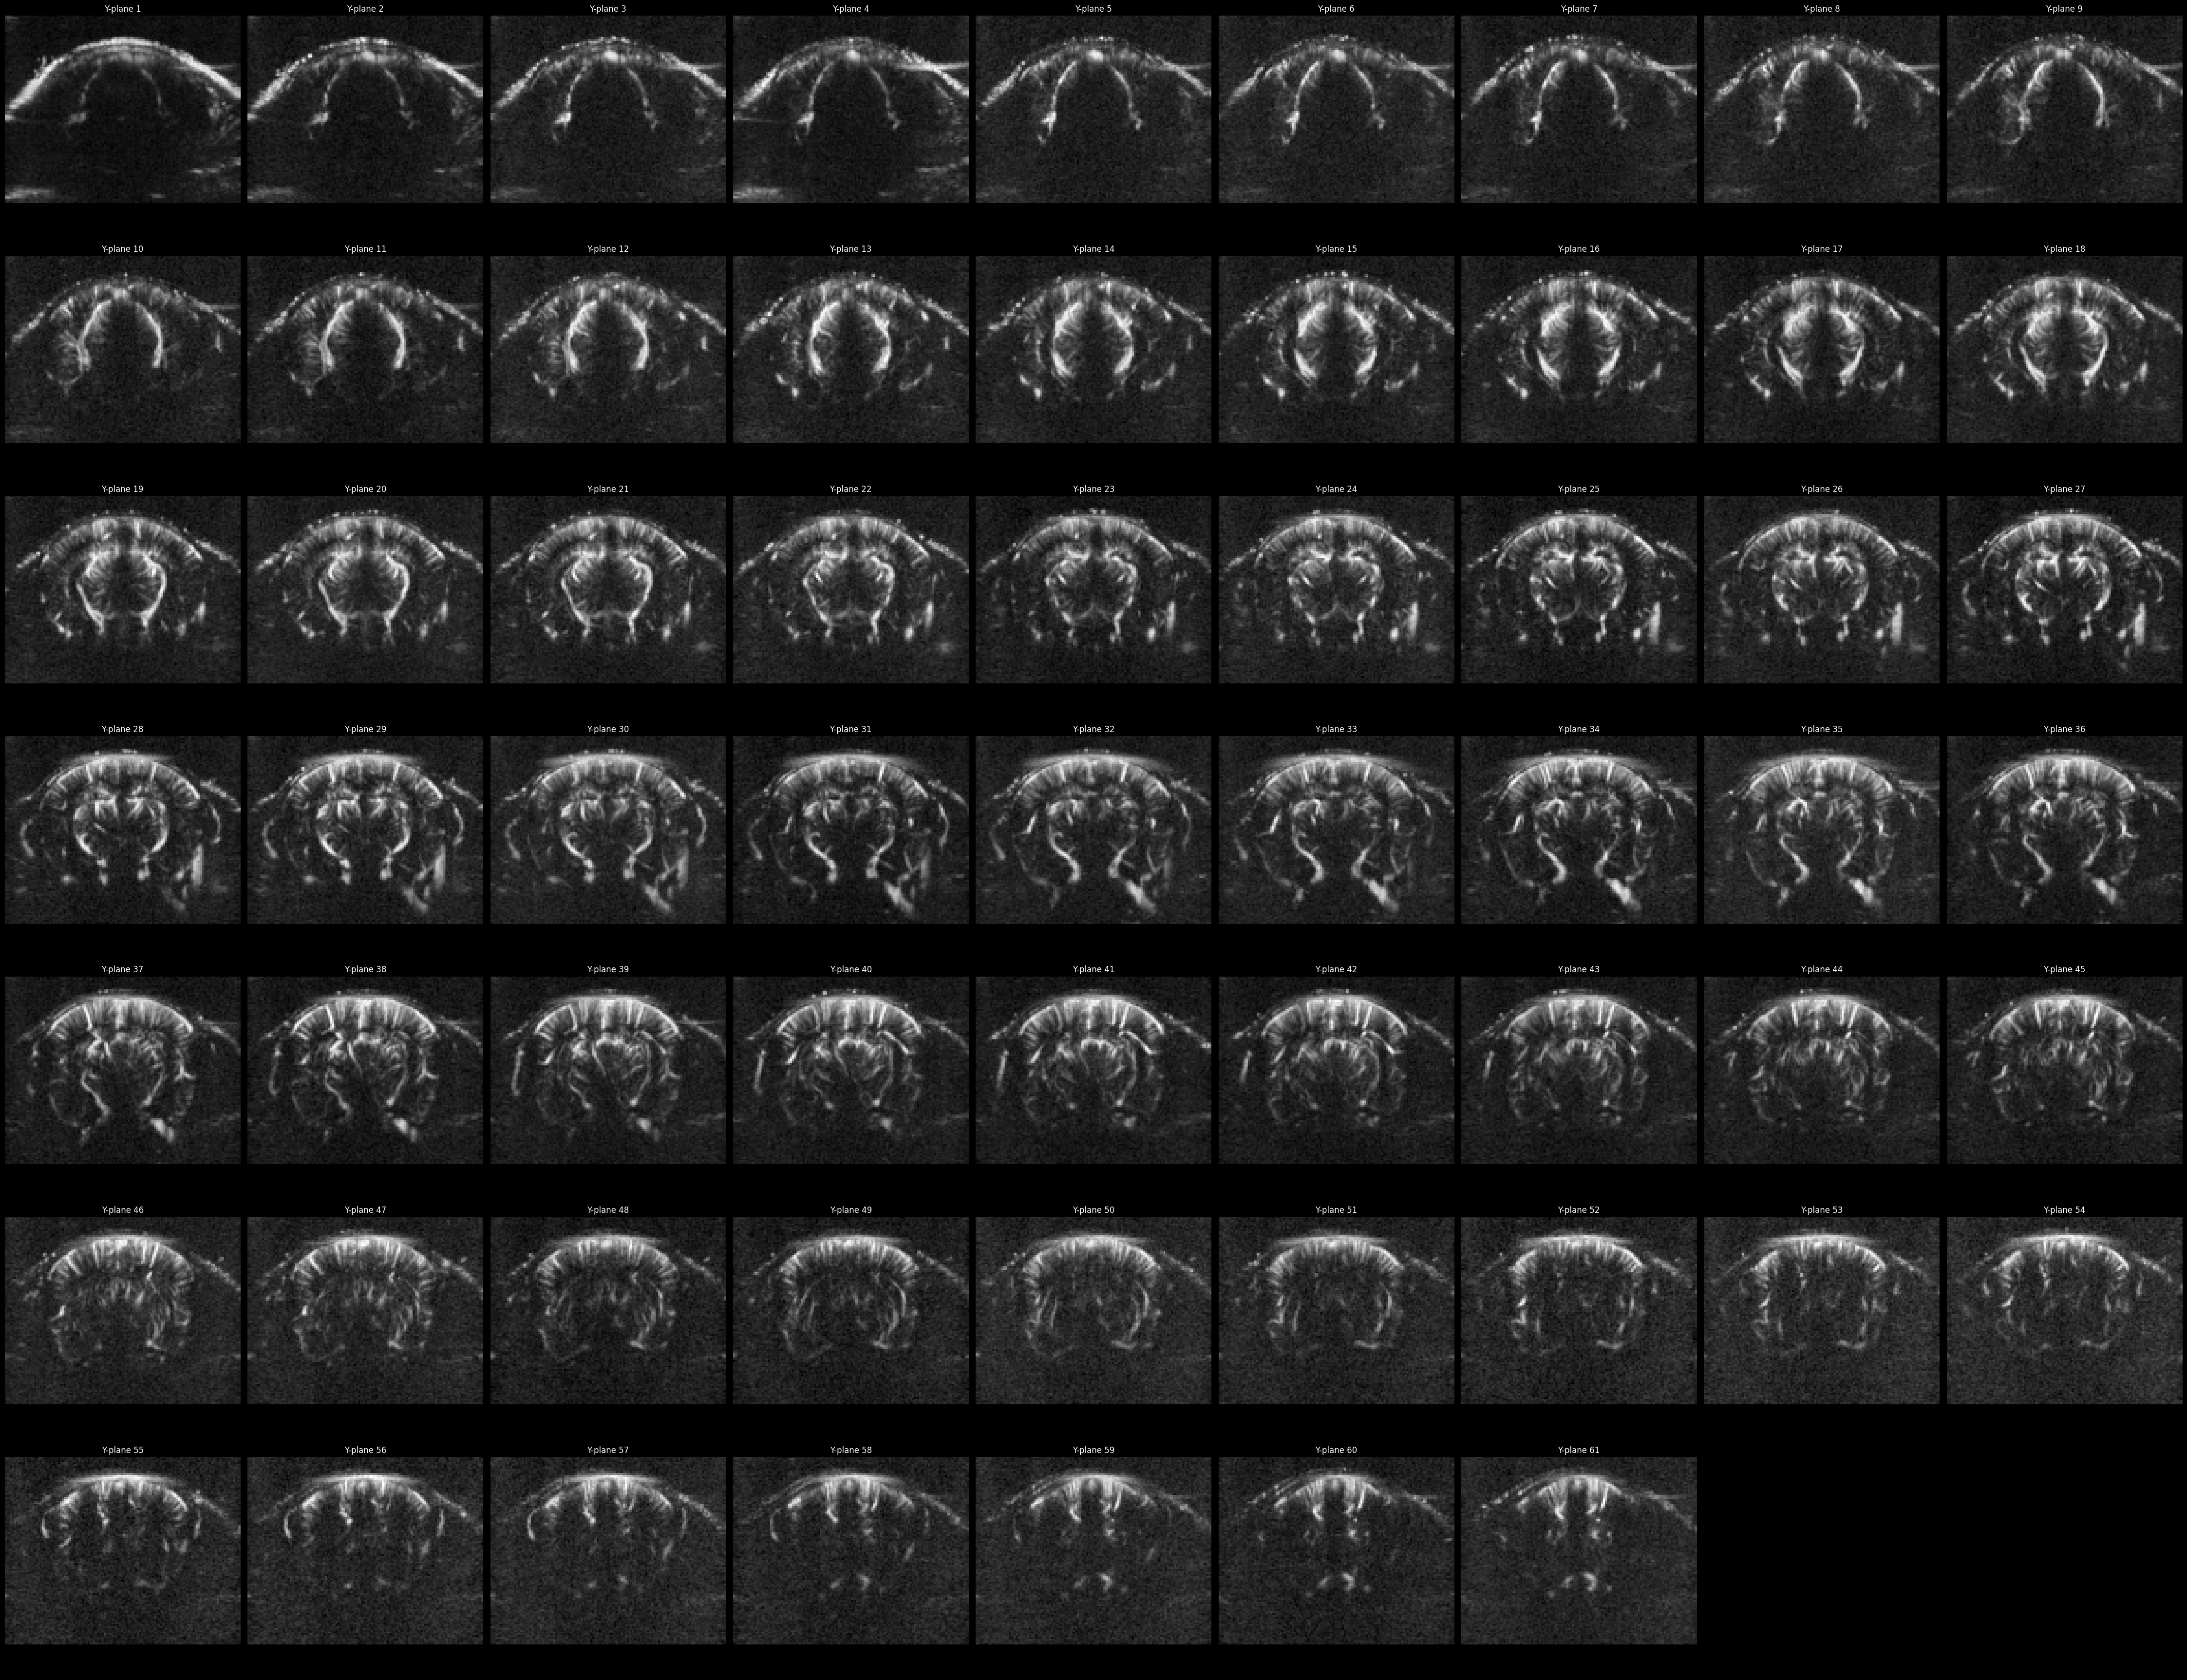

In [1770]:
Doppler3D.show()

In [1771]:
Doppler2D = DopplerScan(scan_PATH=file_scan_2D_PATH)
Doppler2D.summary()

Scan data loaded from ..\src\pysonogen\datatype\Silvia\2Dscan.source.scan. Shape: (775, 102, 1, 128)
Probe to Lab transformation matrix loaded. Shape: (4, 4)
No BPS path provided. No way to get to the Brain space. Returning s_form as identity.
DopplerScan 2D object created successfully.
Data contains zero values. Cannot compute dB scale. No convertion to dB is done.
PyVista mesh reset on Lab coordinate system.
----------DopplerScan Summary:----------
scan_PATH: ..\src\pysonogen\datatype\Silvia\2Dscan.source.scan
bps_PATH: None
probe_type: Linear
mean_frames: True
verbose: False
scan_type: 2D
data: array with shape (128, 1, 102)
probeToLab: [[-9.99999e-01  1.00000e-05  0.00000e+00 -6.64800e-03]
 [-1.00000e-05 -9.99999e-01  0.00000e+00  3.16300e-03]
 [ 0.00000e+00  0.00000e+00  1.00000e+00 -5.13000e-02]
 [ 0.00000e+00  0.00000e+00  0.00000e+00  1.00000e+00]]
voxelsToProbe: [[ 1.10000e-04  0.00000e+00  0.00000e+00 -7.09500e-03]
 [ 0.00000e+00  4.00000e-04  0.00000e+00 -4.00000e-04]
 [ 0.0

c:\Users\INSERM\Documents\Esteban\PySonoGen\.venv\Lib\site-packages\pyvista\core\utilities\points.py:77: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(


Plotting y-planes of scan with shape (128, 1, 102)
Data contains zero values. Cannot compute dB scale. No convertion to dB is done.


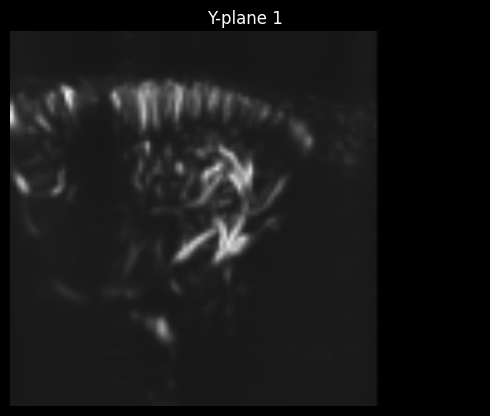

In [1772]:
Doppler2D.show(interpolation = 'bilinear')

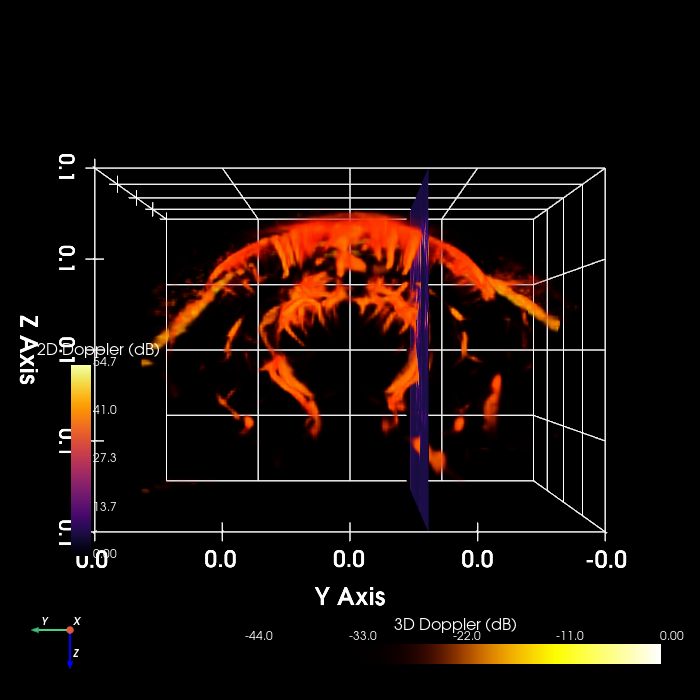

In [ ]:
plotter_lab = add_3D_vol(Doppler3D.pv_mesh, notebook = True, cmap="hot", opacity="sigmoid_10",
                         scalar_bar_args={
                               'title': '3D Doppler (dB)',
                               "title_font_size": 16,
                               "label_font_size": 12,
                               'color' : 'white',
                           })

plotter_lab = add_2D_image(Doppler2D.pv_mesh, plotter=plotter_lab, cmap='inferno', opacity=1.0, show_scalar_bar=True, lighting=True, ambient=1,
                           scalar_bar_args={
                               'title': '2D Doppler (dB)',
                               "title_font_size": 16,
                               "label_font_size": 12,
                               'vertical': True,
                               'position_x': 0.1,
                               'position_y': 0.2,
                               "height": 0.3,
                               'color' : 'white',
                           })

plotter_lab.set_background("black")
plotter_lab.show_grid(color='white')
plotter_lab.add_axes(color='white')
plotter_lab.camera_position = 'yz'  # Set the camera position
plotter_lab.camera.up = (0, 0, -1)  # Set the camera up direction
plotter_lab.show(jupyter_backend='static')


# 3. Import atlas mesh

In [1774]:
atlas_name = "allen_mouse_25um"

if atlas_name == "allen_mouse_25um":
    region_names = ("root")
elif atlas_name == "whs_sd_rat_39um":
    region_names = ("root", "M1", "S1-hl")

Brain_Atlas = BG_Atlas(atlas_name, region_names = region_names)

WHS origin, bregma, and lambda coordinates available for `allen_mouse`.
Structure name: root
PyVista mesh atlas reset.
BrainGlobe Atlas 'allen_mouse_25um' loaded successfully.


In [1775]:
Brain_Atlas.summary()

----------BG_Atlas Summary:----------
atlas_name: allen_mouse_25um
bg_atlas: ┌──────────────────────────────────────────────────────────────────┐
│                         Allen mouse 25um                         │
│                                                                  │
│         name:  allen_mouse (v1.2)                                │
│      species:  Mus musculus                                      │
│     citation:  Wang et al 2020,                                  │
│                https://doi.org/10.1016/j.cell.2020.04.007        │
│         link:  http://www.brain-map.org                          │
│                                                                  │
│  orientation:  asr                                               │
│    symmetric:  True                                              │
│   resolution:  [25.0, 25.0, 25.0]                                │
│        shape:  [528, 320, 456]                                   │
└─────────────────────────

In [1776]:
print(Brain_Atlas)

BG_Atlas(atlas_name=allen_mouse_25um, region_names=root, whs_voxels=None, manual_fit=None)


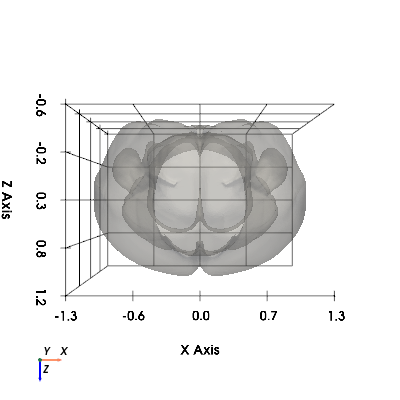

In [1777]:
plotter = add_regions_mesh(Brain_Atlas.pv_mesh, notebook=True, window_size=[400, 400],
                         kwargs_dict={region_names[1]: {"color": "red"}, region_names[2]: {"color": "blue"}})
plotter.show_grid(font_size = 10 )
plotter.camera_position = 'zx'  # Set the camera position
plotter.camera.up = (0, 0, -1)  # Set the camera up direction
plotter.show(jupyter_backend='static')

Structure name: root
PyVista mesh atlas reset.


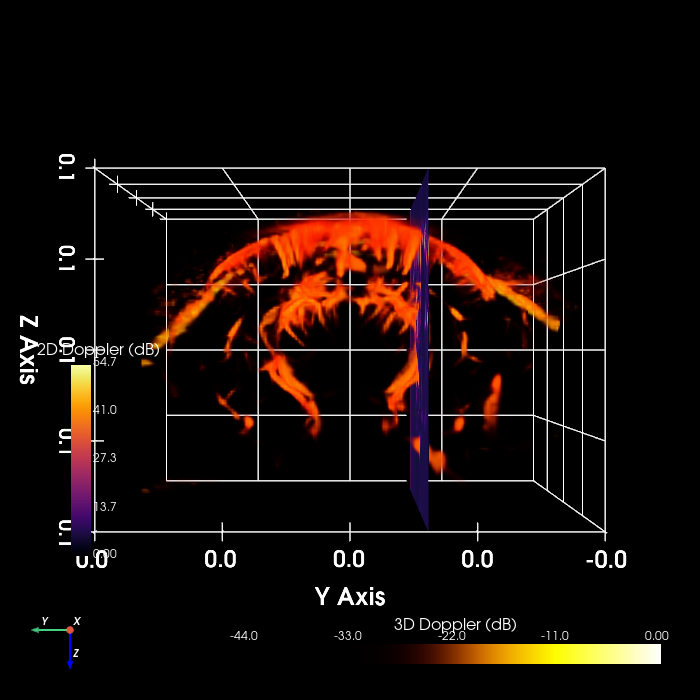

In [1778]:
invertz = np.diag([1, 1, -1, 1])  # Invert z-axis for the transducer mesh
Brain_Atlas.reset_mesh()  # Reset the Brain Atlas mesh to the original mesh
Brain_Atlas.transform(T_matrix = invertz @ Doppler3D.BrainToLab  , inplace=True) 

plotter_lab = add_regions_mesh(Brain_Atlas.pv_mesh, plotter=plotter_lab)
plotter_lab.render()
plotter_lab.show(jupyter_backend='static')

# 4 Import transducer

During the experiment we have 3 spaces: Brain, Lab, Probe. Once we manage to have our atlas in lab coordinates, we could simplify them to Lab and probe. The lab reference frame will move averything around the probe reference frame. Then its pov is static. We must then take our transducer, set . The probe space will have its origin center in the probe, and if we have done a good aproximation of the length and height, then its x,y coordinates should not move

In [1749]:
import pysonogen.transducers as Transducers

print(Transducers.available_transducers())
# Create transducer with elevation focus
n_elements = 128
pitch_mm = 0.11
element_width_mm = 0.108
element_height_mm = 1.5
elevation_focus_mm = 8  # mm
tx_freq = 12.5  # MHz


domino = Transducers.LinearArrayTransducer(
    n_elements         = n_elements,
    element_width_mm   = element_width_mm,
    element_height_mm  = element_height_mm,
    elevation_focus_mm = elevation_focus_mm,
    kerf_mm            = pitch_mm - element_width_mm,
    no_sub_x           = 1,
    no_sub_y           = 10,
    frequency_Hz       = tx_freq*1e6,  # MHz),
)

print(domino)


['LinearArrayTransducer', 'MatrixArrayTransducer']
Transducer initialized in 0.0093 seconds.
LinearArrayTransducer(n_elements=128, el_w_mm=0.108, el_h_mm=1.5, kerf_mm=0.002000000000000002, elev_focus_mm=8.0, no_sub_x=1, no_sub_y=10, fc_Hz=12500000.0, Apod type=None, tx_N_active=128, F_over_D=None)


Focus: -1.000 mm, 0.000 mm, 4.500 mm


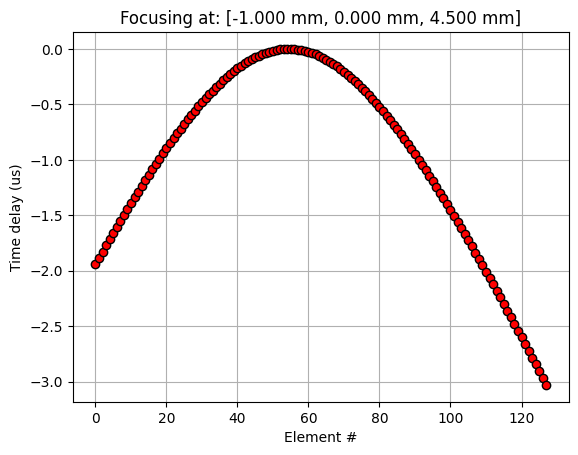

Focus: -1.000 mm, 0.000 mm, 4.500 mm


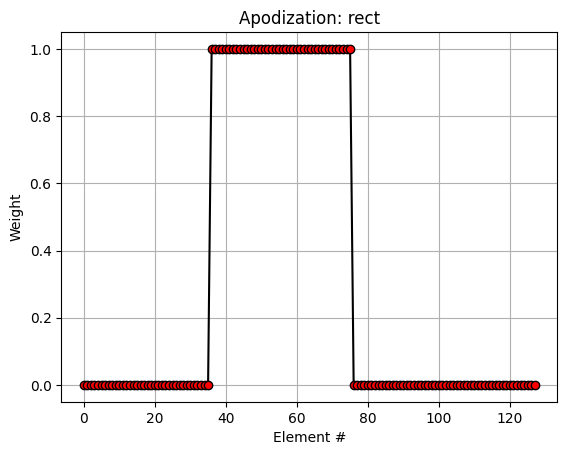

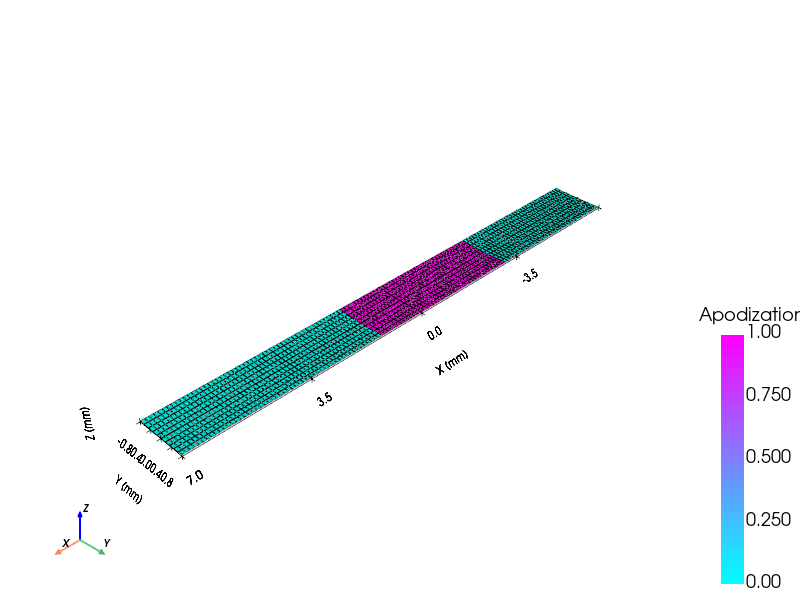

In [1750]:
from pysonogen import pyfield

# Focalization spot
focus_mm =  np.array([-1, 0, 4.5])  # mm [x, y, z]
delays = domino.compute_delays(focus_mm = focus_mm, plot = True)
apodization = domino.compute_apodization(focus_mm = focus_mm, F_over_D = 1, apodization_type='rect', plot = True)
domino.show(jupyter_backend='static')

In [1751]:
TX_mesh = domino.get_mesh()

# 4. Take scan and atlas to probe space

In this case, the probe space will be located at the last plane acquisition thus on the 2D doppler image. Therefore, we must take the lab space back to the probe space of the 2D acquisition. However, we must first take the atlas to the lab space with the BPS information, and we must also fix the center of the transducer which is not the same.

In [1752]:
invertz = np.diag([1, 1, -1, 1])  # Invert
# Set the TX mesh origin
x_min, x_max, y_min, y_max, z_min, z_max = TX_mesh.bounds
TX_origin = np.array([x_min, y_min])
Probe_origin = Doppler2D.voxelsToProbe[:2, 3]   # Set the origin to the mesh bounds

set_TX_origin = np.eye(4)  # Create a 4x4 identity matrix for translation
set_TX_origin[:2, 3] =  Probe_origin - TX_origin*1e-3  # Compute the translation vector to the transducer origin

# rescale units from m to mm
rescale_mToMm = np.diag([1000, 1000, 1000, 1])  # Scale factors for x, y, z, and homogeneous coordinate

LabToProbe =  invertz @ rescale_mToMm @ set_TX_origin @ np.linalg.inv(Doppler2D.probeToLab) @ invertz  # Invert the probe to lab transformation matrix




In [1753]:
Scan3D_probe = Doppler3D.transform(T_matrix= LabToProbe, inplace=False)  # Transform the scan mesh to the probe coordinate system
Scan2D_probe = Doppler2D.transform(T_matrix= LabToProbe, inplace=False)  # Transform the scan mesh to the probe coordinate system
BrainReg_probe = Brain_Atlas.transform(T_matrix= LabToProbe, inplace=False)  # Transform the atlas mesh to the probe coordinate system

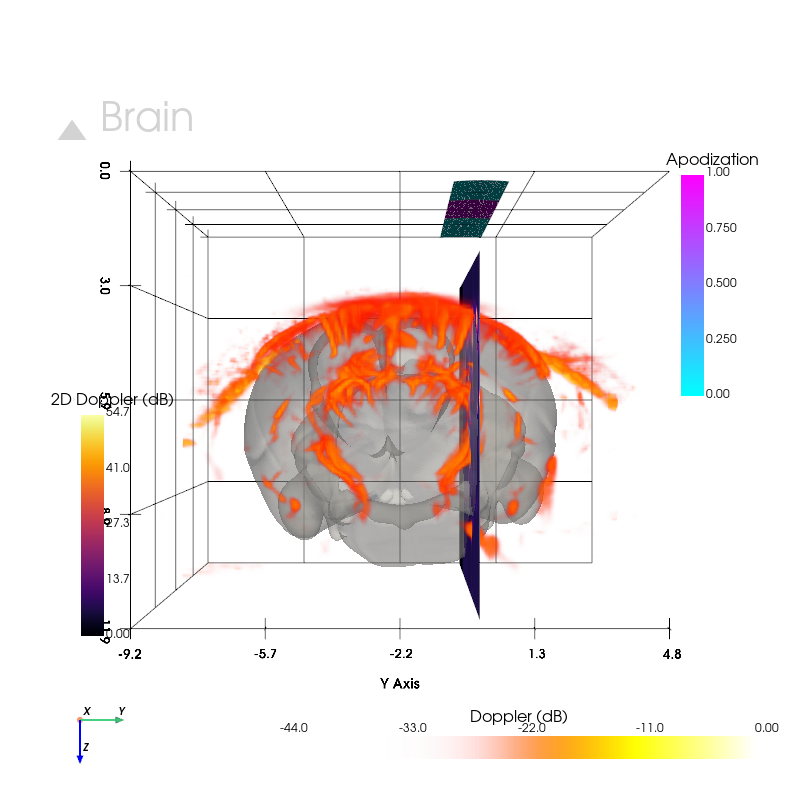

In [1790]:
plotter3 = add_regions_mesh(BrainReg_probe,
                            notebook=True, window_size=[800, 800],
                            kwargs_dict={region_names[0]: {"color": "lightgray", "opacity": 0.2},	 
                                        region_names[1]: {"color": "permanentgreen", "opacity": 0.4}, 
                                        region_names[2]: {"color": "cadmiumlemon", "opacity": 0.6}})

plotter3 = add_3D_vol(Scan3D_probe, plotter = plotter3, cmap="hot", opacity="sigmoid_10")

plotter3 = add_transducer_mesh(TX_mesh,
                        plotter=plotter3, show_edges=False)

plotter3 = add_2D_image(Scan2D_probe, plotter=plotter3, cmap='inferno', opacity=1.0, show_scalar_bar=True, lighting=True, ambient=1)

plotter3.show_axes()
plotter3.show_grid(
    font_size = 10
)

plotter3.camera_position = 'zy'  # Set the camera position
plotter3.camera.up = (0, 0, -1)
plotter3.add_legend(loc = 'upper left')             # show legend
plotter3.set_background('white')  # Set background color to white
plotter3.show(jupyter_backend='static') # ,

# 5. Add Pressure Field

In [1755]:
Domino_field = pyfield.PyField(domino)
field_info_mm = {
    "x_extent" : [-0.25+focus_mm[0], 0.25+focus_mm[0]],
    "y_extent" : [-0.5+focus_mm[1], 0.5+focus_mm[1]],
    "z_extent" : [-1+focus_mm[2], 1+focus_mm[2]],
    "dx" : 0.0125,
    "dy" : 0.025,
    "dz" : 0.05,
}
print("Field info:", field_info_mm)
pressure_field, x, y, z = Domino_field.compute_pressure_field(field_info_mm)

Successfully initialized PyField with 
 LinearArrayTransducer(n_elements=128, el_w_mm=0.108, el_h_mm=1.5, kerf_mm=0.002000000000000002, elev_focus_mm=8.0, no_sub_x=1, no_sub_y=10, fc_Hz=12500000.0, Apod type=rect, tx_N_active=40, F_over_D=1)
Field info: {'x_extent': [np.float64(-1.25), np.float64(-0.75)], 'y_extent': [np.float64(-0.5), np.float64(0.5)], 'z_extent': [np.float64(3.5), np.float64(5.5)], 'dx': 0.0125, 'dy': 0.025, 'dz': 0.05}
Creating simulation grid...
Computing spatial impulse response...
Computing SIR for 68921 points and 1280 patches...
Computing all patch events...
Accumulating SIR from events...
Total computation time: 15.5280 seconds.
Computing pressure field...
Original h shape: (512, 68921)
Reshaped h shape: (512, 41, 41, 41)
Performing FFT...
Frequency searched: 12500000.0 Hz. Found: 12328767.123287672 Hz


Taking slice x_ind, y_ind, z_ind = 21/41, 21/41, 21/41


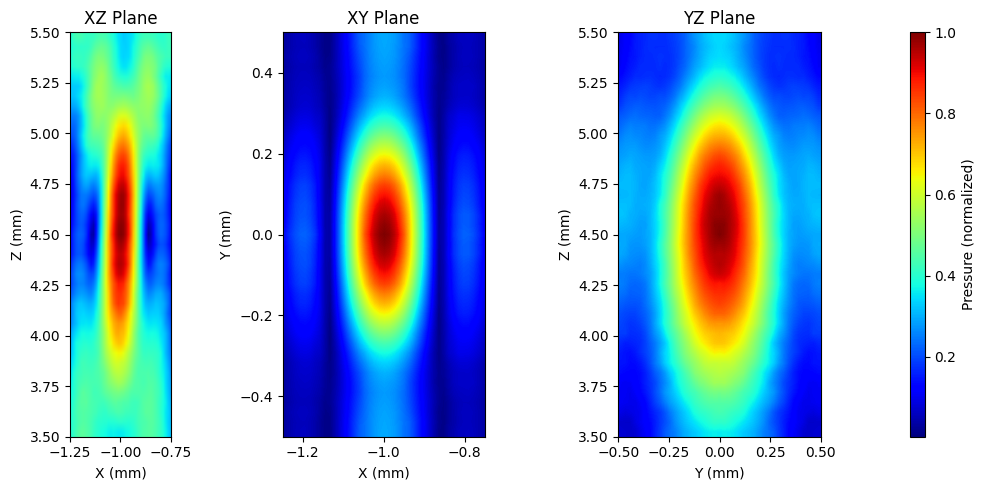

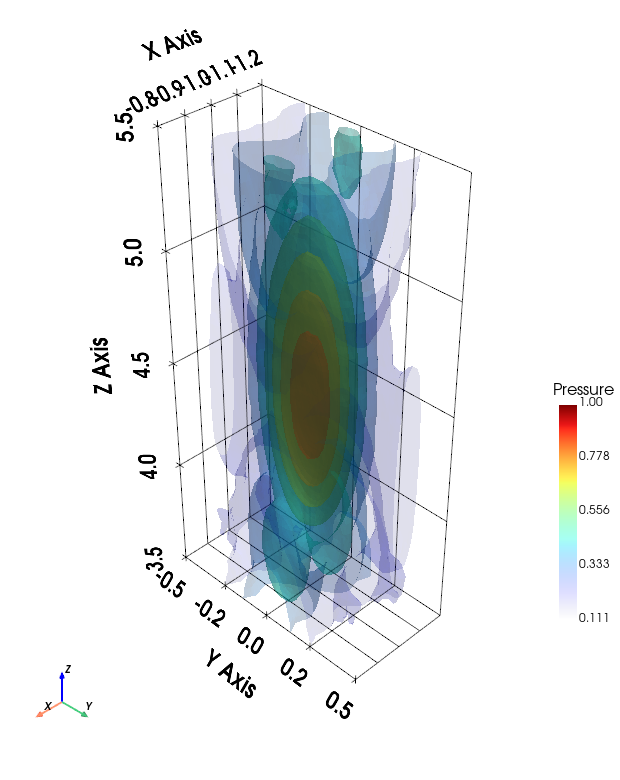

In [1756]:
import pysonogen
pysonogen.plot_field_planes(pressure_field,
                               x, y, z, figsize = (10, 5), interpolation="bilinear")

pressure_plotter, pressure_vol_mesh = pysonogen.plot_pressure_field(pressure_field,
                               x, y, z, notebook = True, return_mesh = True, window_size = [620, 780])

pressure_plotter.show(jupyter_backend='static')  # Add this parameter

# 5. Plot brain and pressure field

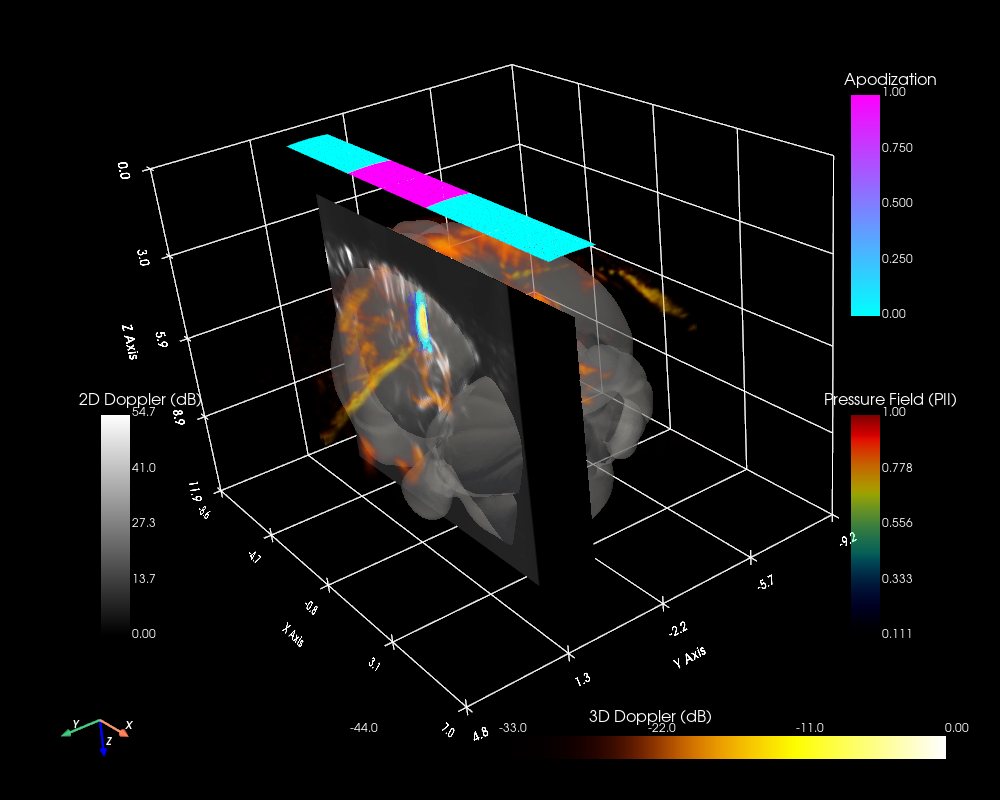

In [1808]:
final_plotter = add_regions_mesh(BrainReg_probe,
                            notebook=True, window_size=[1000, 800],
                            kwargs_dict={region_names[0]: {"color": "lightgray", "opacity": 0.1},	 
                                        region_names[1]: {"color": "permanentgreen", "opacity": 0.2}, 
                                        region_names[2]: {"color": "cadmiumlemon", "opacity": 0.2}}, label = "Brain Atlas")

final_plotter = add_3D_vol(Scan3D_probe, plotter = final_plotter,
                                cmap="hot", opacity="sigmoid", opacity_unit_distance = 1,
                                scalar_bar_args={
                                    'title': '3D Doppler (dB)',
                                    "title_font_size": 16,
                                    "label_font_size": 12,
                                    'color' : 'white',
                                })

final_plotter = add_2D_image(Scan2D_probe, plotter=final_plotter, cmap='gray', opacity=1.0, show_scalar_bar=True, lighting=True, ambient=1,
                             scalar_bar_args={
                                    'title': '2D Doppler (dB)',
                                    "title_font_size": 16,
                                    "label_font_size": 12,
                                    'vertical': True,
                                    'position_x': 0.1,
                                    'position_y': 0.2,
                                    "height": 0.3,
                                    'color' : 'white',
                                })
                                 

final_plotter = add_transducer_mesh(TX_mesh,
                        plotter=final_plotter, show_edges=False, lighting=True, ambient=1,
                        scalar_bar_args={
                            'title': 'Apodization',
                            "title_font_size": 16,
                            "label_font_size": 12,
                            'vertical': True,
                            'position_x': 0.85,
                            'position_y': 0.6,
                            "height": 0.3,
                            'color' : 'white',
                        })

final_plotter = add_pressure_vol(pressure_vol_mesh,
                        plotter=final_plotter,
                        plot_focal_spot=False, lighting=True, ambient=1,
                        scalar_bar_args={
                            'title': 'Pressure Field (PII)',
                            "title_font_size": 16,
                            "label_font_size": 12,
                            'vertical': True,
                            'position_x': 0.85,
                            'position_y': 0.2,
                            "height": 0.3,
                            'color' : 'white',
                        })

# final_plotter.camera.up = (0, 0, -1)
# final_plotter.show_axes()
# final_plotter.show_grid(
#     font_size = 10
# )
final_plotter.set_background("black")
final_plotter.show_grid(color='white', font_size=10)  # Show grid with white color and font size 10
final_plotter.add_axes(color='white')
final_plotter.camera_position = 'zy'  # Set the camera position
final_plotter.camera.up = (0, 0, -1)  # Set the camera up direction
final_plotter.camera_position = [(35.3553561681614, 20.196200713709917, -14.240798942058916),
 (0.35035573008308757, -1.5421982237567053, 7.3213329246801795),
 (-0.3315987278689962, -0.33921900362926793, -0.8803253666982627)]
final_plotter.show(jupyter_backend='static')  # Show the plotter in Jupyter Notebook

In [ ]:
make_movie = False

if make_movie:

    video_plotter = add_regions_mesh(BrainReg_probe,
                                notebook=False, window_size=[1200, 800],
                                kwargs_dict={region_names[0]: {"color": "lightgray", "opacity": 0.1},	 
                                            region_names[1]: {"color": "permanentgreen", "opacity": 0.2}, 
                                            region_names[2]: {"color": "cadmiumlemon", "opacity": 0.2}})

    video_plotter = add_3D_vol(Scan3D_probe, plotter = video_plotter,
                                    cmap="hot", opacity="sigmoid", opacity_unit_distance = 1)

    video_plotter = add_transducer_mesh(TX_mesh,
                            plotter=video_plotter, show_edges=False)

    video_plotter = add_2D_image(Scan2D_probe, plotter=video_plotter, cmap='gray', opacity=1.0, show_scalar_bar=True, lighting=True, ambient=1)

    video_plotter = add_pressure_vol(pressure_vol_mesh,
                            plotter=video_plotter,
                            plot_focal_spot=True, lighting=True, ambient=1)

    video_plotter.camera.up = (0, 0, -1)
    video_plotter.camera_position = 'zx'  # Set the camera position
    video_plotter.show_axes()
    video_plotter.show_grid(
        font_size = 10
    )
    video_plotter.add_legend(loc = 'upper left')             # show legend


    # Render once before movie to apply camera and settings
    video_plotter.render()

    # Open movie file and define frame settings
    n_frames = 180
    video_filename = "sonogen_experiment.mp4"
    video_plotter.open_movie(video_filename, framerate=20)

    # Rotation loop
    video_plotter.show(auto_close=False)

    delta_angle_deg = 360 / n_frames
    angle_deg = 0 
    for i in range(n_frames):
        angle_deg += 2
        video_plotter.camera.azimuth = angle_deg # Rotate camera
        video_plotter.render()
        video_plotter.write_frame()

    # Finalize and save
    video_plotter.close()
    print(f" Video saved to: {video_filename}")